# FILL NULLS IN ENVIRONMENTAL DATA

## Firstly all libraries are imported into the file
This step is crucial and needs to run every single time the file is used

In [1]:
import sys
print(sys.executable)

/home/tim/OneDrive/fedora/Documents/SEMESTER4/int/werkstudent/N2-fixers-in-the-ocean/.venv/bin/python


In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import joblib as joblib
from sklearn.impute import KNNImputer

In [3]:
from format import constructFeatures
from visualize import plotColsOnMap

## Loading the raw data into file as env_df
The number of null values is almost negligible compared to real values. It only needs filling for Fe. However, as we later discovered, not all points in bacterial data find a match in environmental data and need to be extrapolated on in order to achive more data points where both NifH and environmental data is known even in approximation. Thus adding a significant amount of computational work to the problem.

First we load the dataset with 3 spacial coordinates: 'LATITUDE', 'LONGITUDE', 'DEPTH (m).

In [4]:
env_df = pd.read_csv("../csv/features/env_data.csv") 
print(env_df.columns)
env_df.info(show_counts=True)

Index(['LATITUDE', 'LONGITUDE', 'DEPTH (m)', 'O2', 'T', 'P', 'N', 'Fe',
       'solar'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1975826 entries, 0 to 1975825
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1975826 non-null  int64  
 1   LONGITUDE  1975826 non-null  int64  
 2   DEPTH (m)  1975826 non-null  int64  
 3   O2         1975826 non-null  float64
 4   T          1975826 non-null  float64
 5   P          1975826 non-null  float64
 6   N          1975826 non-null  float64
 7   Fe         1444228 non-null  float64
 8   solar      1975826 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 135.7 MB


These are initial columns that form 2 groups: spatial coordinates and environmental data that form input values for the future model

In [5]:
data_cols = ['O2', 'T', 'N', 'P',"Fe", "solar"]
cor_cols = ['LATITUDE', 'LONGITUDE', "DEPTH (m)"]

In [6]:
env_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),O2,T,P,N,Fe,solar
count,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.975826e+06,1.444228e+06,1.975826e+06
mean,-5.690829e+00,-1.105118e+01,2.493891e+01,2.617499e+02,1.440107e+01,6.793435e-01,7.317749e+00,2.362368e-01,1.527234e+02
std,4.456032e+01,1.095417e+02,1.491995e+01,5.906114e+01,1.091352e+01,6.121472e-01,9.313503e+00,2.618983e-01,2.791681e+01
min,-7.800000e+01,-1.800000e+02,0.000000e+00,1.144983e+01,-1.888110e+00,3.282310e-03,0.000000e+00,0.000000e+00,7.855326e+01
25%,-4.400000e+01,-1.120000e+02,1.500000e+01,2.075293e+02,3.269510e+00,1.740894e-01,2.995195e-01,4.225958e-02,1.293318e+02
50%,-1.200000e+01,-2.000000e+01,2.500000e+01,2.472372e+02,1.625879e+01,4.271380e-01,2.198116e+00,1.755046e-01,1.543691e+02
75%,2.600000e+01,8.400000e+01,3.500000e+01,3.158121e+02,2.504371e+01,1.113223e+00,1.230046e+01,3.299320e-01,1.784812e+02
max,9.000000e+01,1.780000e+02,5.000000e+01,5.041048e+02,3.029479e+01,2.688223e+00,4.080209e+01,3.316630e+00,1.952198e+02


This section can plot the data if needed but is commneted out to avoid too long execution

In [7]:
#plotColsOnMap(data_cols, env_df) can use the graph from previous file
#env_df = removeEmptyRows(data_cols, env_df) no need for this as clearly all rows have data

## Adding coordinates
As mentioned above some points not present here should have an approximation.

So, the bacterial data is loaded and then extrapolated on in further sections.

In [8]:
# I load bacterial data and copy the env coordinates for use
bact_data = pd.read_csv("../csv/features/bact_data.csv")
env_df_coord = env_df.copy()

# datasets are merged with an outer join, indicator tells us if a row is in one, the other or both
comparison_join = pd.merge(bact_data, env_df_coord, on=cor_cols, how="outer", indicator=True)
difference_df = comparison_join[comparison_join['_merge'] == 'left_only']

# now we can merge the environmental data with rows that need to be extrapolated on
# the length check is just to make sure that everything is correct
dif_len = len(difference_df)
env_len = len(env_df)
print("\nnumber of rows in difference is {0} number of rows in env data is {1}".format(len(difference_df), len(env_df)))
env_df = pd.merge(env_df, difference_df[cor_cols], on=cor_cols, how="outer").reset_index()[data_cols+cor_cols]
print("after joining the lngth is {0} and it should be {1}\n".format(len(env_df), (dif_len+env_len)))

env_df.info(show_counts=True)


number of rows in difference is 6528 number of rows in env data is 1975826
after joining the lngth is 1982354 and it should be 1982354

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982354 entries, 0 to 1982353
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   O2         1975826 non-null  float64
 1   T          1975826 non-null  float64
 2   N          1975826 non-null  float64
 3   P          1975826 non-null  float64
 4   Fe         1444228 non-null  float64
 5   solar      1975826 non-null  float64
 6   LATITUDE   1982354 non-null  int64  
 7   LONGITUDE  1982354 non-null  int64  
 8   DEPTH (m)  1982354 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 136.1 MB


Computing the mean on the entire globe is inaccurate and doesn't work well. However, if we select the bacterial data only it should approximate way better.

In [9]:
#we need to find averages in bacterial data so i perform an inner join and compute the mean
bact_typical_data = comparison_join[comparison_join['_merge'] == 'both']

typical_mean = bact_typical_data[data_cols].mean()

## Simple fill
The first strategy is to use mean value for each column to fill the missing data. Here I use a mean value that is true for bacterial data specifically. Thus, accuracy is low, but higher than taking an average for the entire environmental data.

In [10]:
#we create a dictionary with mean value for each column name
means = typical_mean

In [11]:
#we fill values and see the results in info
env_simple_fill = env_df.fillna(value=means)
env_simple_fill.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982354 entries, 0 to 1982353
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   O2         1982354 non-null  float64
 1   T          1982354 non-null  float64
 2   N          1982354 non-null  float64
 3   P          1982354 non-null  float64
 4   Fe         1982354 non-null  float64
 5   solar      1982354 non-null  float64
 6   LATITUDE   1982354 non-null  int64  
 7   LONGITUDE  1982354 non-null  int64  
 8   DEPTH (m)  1982354 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 136.1 MB


In [12]:
#I saved the results this can be useful for plotting them in a separate file
env_simple_fill.to_csv("../csv/filled/env_data_simple_fill.csv", index=False)

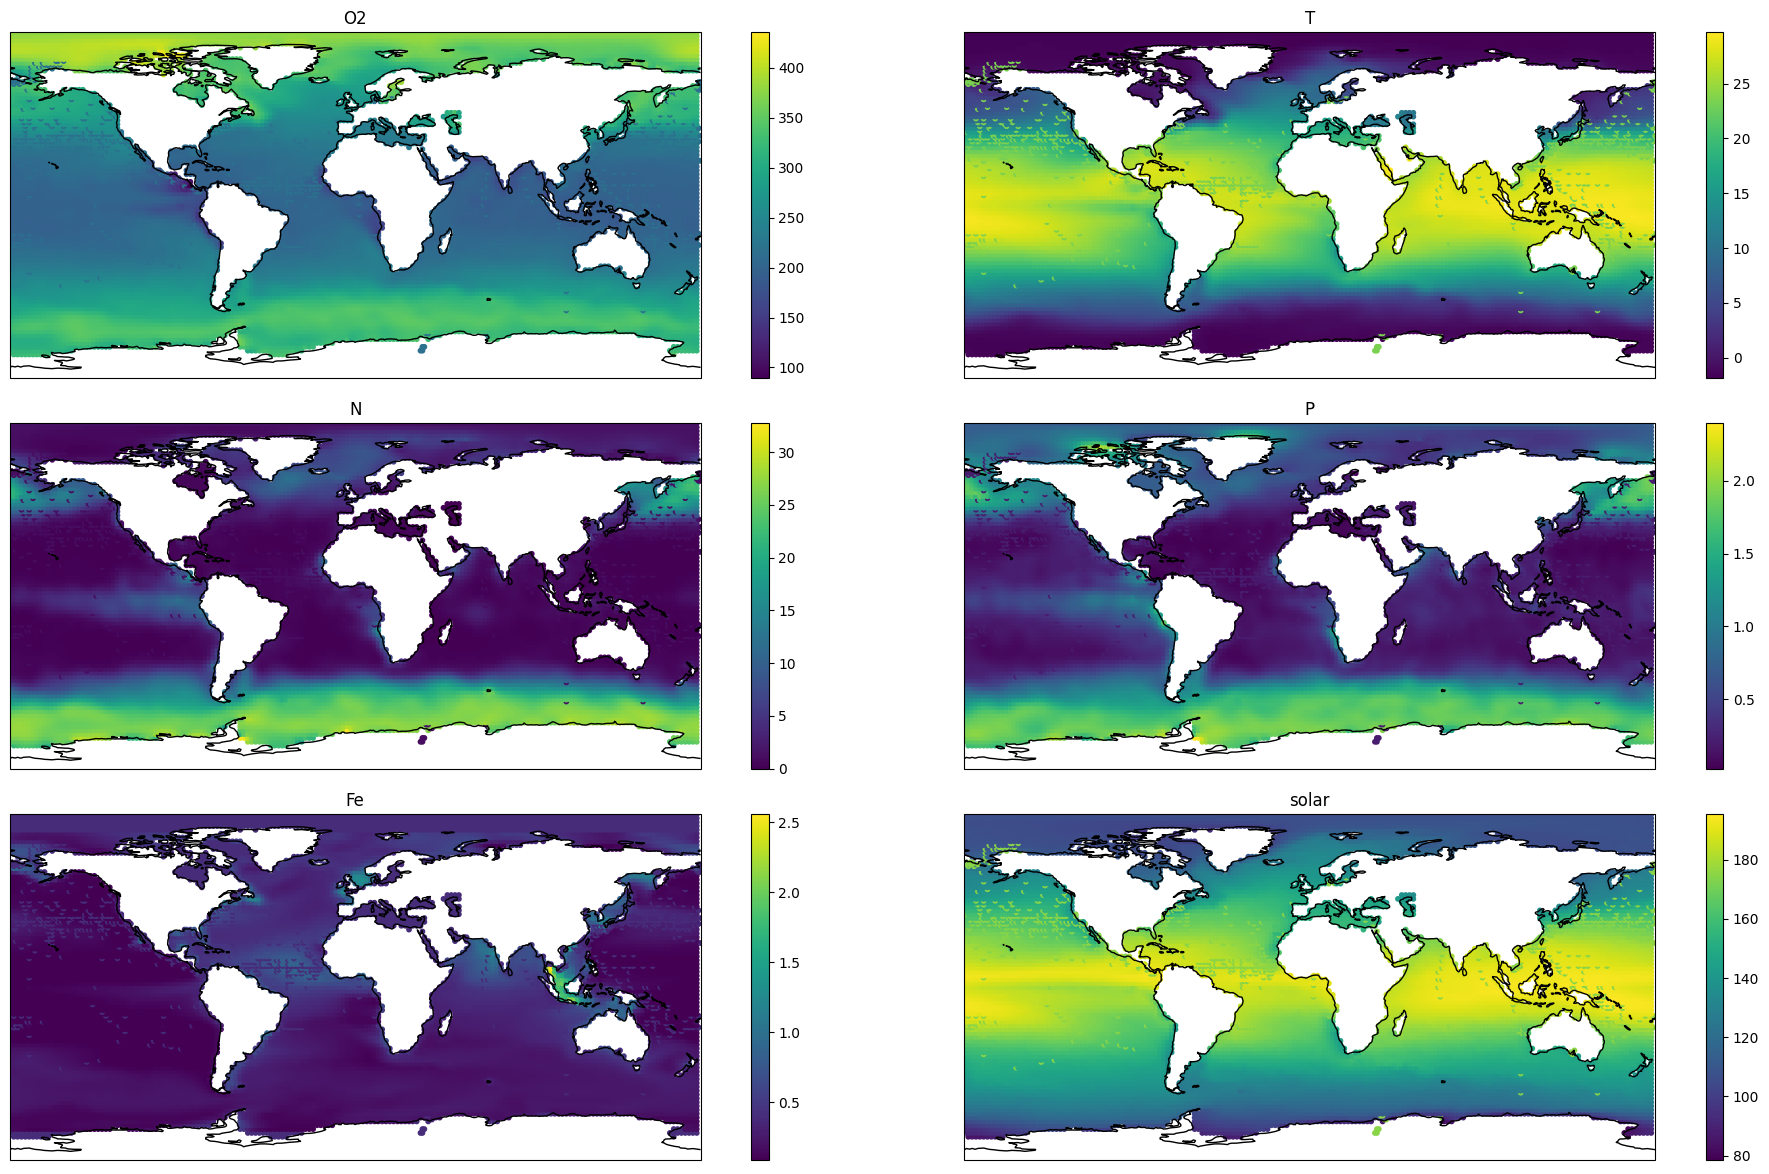

In [13]:
#here the imputed values can be clearly seen on the map for the simple imputer (execution time: 3:20 min)
plotColsOnMap(data_cols, env_simple_fill, constant =1, s=10)

## Complex fill
In this part I aimed to use coordinates in order to figure out what the best missing value might be.

### Latitude average
The first approach I wanted to try was Latitude based average. So, instead of taking the average of the entire planet, which can yield inaccurate results, we only use points on the same latitude. 

I think this can be quite good as the initial data clearly varies a lot based on latitude and thus, latitude is an important factor that should be accounted for when filling in the gaps.

In [14]:
avg_cols = []

for col in data_cols:
    avg_col = env_df.groupby('LATITUDE')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    avg_cols.append(avg_col)

env_lat_fill = pd.concat([env_df[cor_cols]]+avg_cols, axis=1)

env_lat_fill.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982354 entries, 0 to 1982353
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1982354 non-null  int64  
 1   LONGITUDE  1982354 non-null  int64  
 2   DEPTH (m)  1982354 non-null  int64  
 3   O2         1978553 non-null  float64
 4   T          1978553 non-null  float64
 5   N          1978553 non-null  float64
 6   P          1978553 non-null  float64
 7   Fe         1907203 non-null  float64
 8   solar      1978553 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 136.1 MB


The code below shows that in the original dataframe not all latitudes have data present and thus leave missing values.

In [15]:
check = env_df.groupby('LATITUDE')[data_cols].mean().isna()

check.sum()

O2       62
T        62
N        62
P        62
Fe       69
solar    62
dtype: int64

### Filling in the remaining nulls
And the value for Fe is filled with average because we need no null values in the dataset. So in the final results we get no missing values. 

In [16]:
data_cols_lat = data_cols

#we create a dictionary with mean value for each column name
means = dict(typical_mean)

#this is for further data analysis to see the means more clearly on the graphs
print(means)

#beforehand the data is copied to use without the mean replacement
env_lat_fill_nomean = env_lat_fill.copy()

#we fill values and see the results in info
env_lat_fill.fillna(value=means, inplace=True)
env_lat_fill.info(show_counts=True)

{'O2': np.float64(218.49640354433055), 'T': np.float64(23.395889776449327), 'N': np.float64(1.0936827470481245), 'P': np.float64(0.2139983300511466), 'Fe': np.float64(0.38833115260831114), 'solar': np.float64(174.66983147310577)}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982354 entries, 0 to 1982353
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1982354 non-null  int64  
 1   LONGITUDE  1982354 non-null  int64  
 2   DEPTH (m)  1982354 non-null  int64  
 3   O2         1982354 non-null  float64
 4   T          1982354 non-null  float64
 5   N          1982354 non-null  float64
 6   P          1982354 non-null  float64
 7   Fe         1982354 non-null  float64
 8   solar      1982354 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 136.1 MB


As we can see this method is not that computationally intensive, but manages to produce way better results overall.

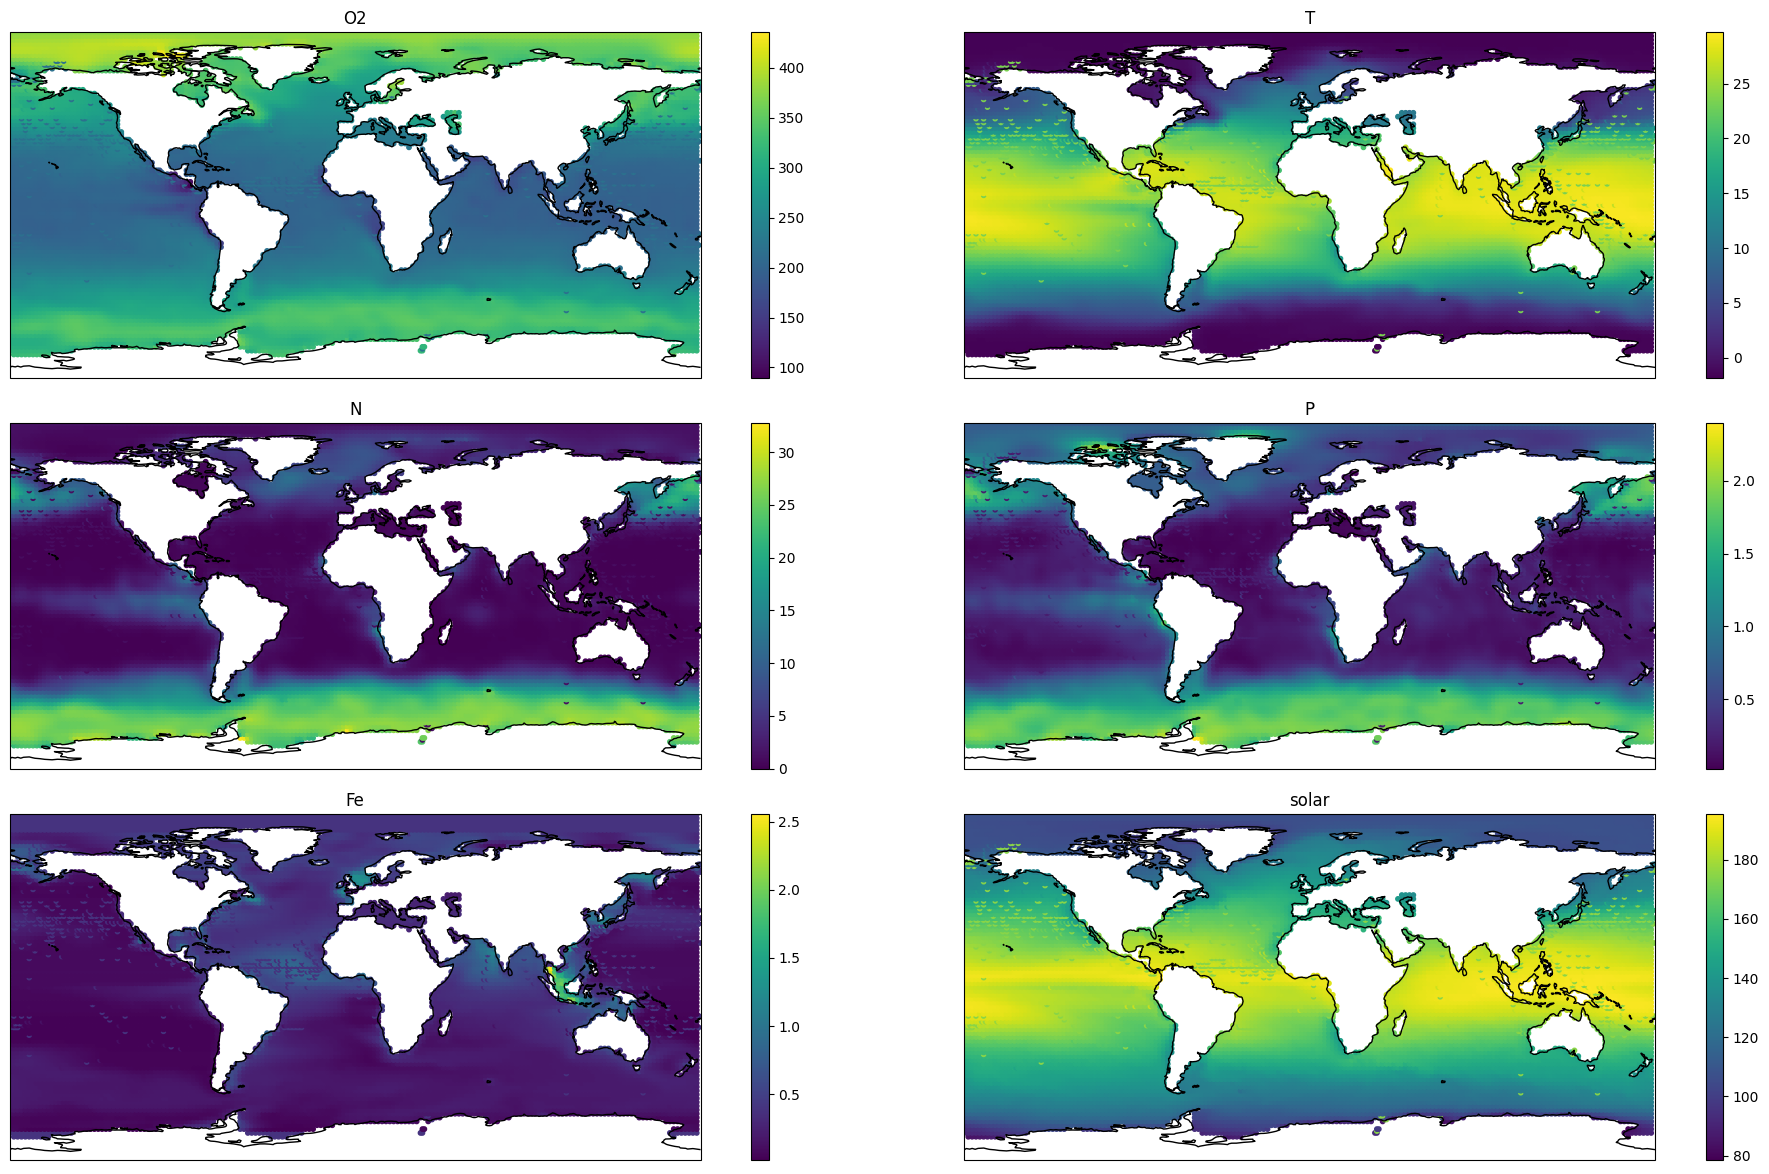

In [17]:
# latitude fill based plot approximately 4 min to execute
plotColsOnMap(data_cols, env_lat_fill, constant=1, s=10)

In [18]:
env_lat_fill.describe()

,LATITUDE,LONGITUDE,DEPTH (m),O2,T,N,P,Fe,solar
count,1.982354e+06,1.982354e+06,1.982354e+06,1.982354e+06,1.982354e+06,1.982354e+06,1.982354e+06,1.982354e+06,1.982354e+06
mean,-5.629294e+00,-1.107515e+01,2.504772e+01,2.616101e+02,1.442929e+01,7.298158e+00,6.779076e-01,2.435989e-01,1.527927e+02
std,4.452202e+01,1.096032e+02,1.579309e+01,5.902866e+01,1.090958e+01,9.305156e+00,6.117173e-01,2.307525e-01,2.790539e+01
min,-7.800000e+01,-1.800000e+02,0.000000e+00,1.144983e+01,-1.888110e+00,0.000000e+00,3.282310e-03,0.000000e+00,7.855326e+01
25%,-4.400000e+01,-1.120000e+02,1.500000e+01,2.075523e+02,3.312290e+00,3.009967e-01,1.743215e-01,1.013378e-01,1.293744e+02
50%,-1.200000e+01,-2.000000e+01,2.500000e+01,2.468288e+02,1.634381e+01,2.174774e+00,4.246606e-01,1.873999e-01,1.544830e+02
75%,2.600000e+01,8.400000e+01,3.500000e+01,3.156349e+02,2.503919e+01,1.223223e+01,1.109187e+00,3.429775e-01,1.784752e+02
max,1.200000e+02,1.870000e+02,1.700000e+03,5.041048e+02,3.029479e+01,4.080209e+01,2.688223e+00,3.316630e+00,1.952198e+02


In [19]:
env_lat_fill.to_csv("../csv/filled/env_data_lat_fill.csv", index=False)

#### Imputing remaining missing values
Here I try to impute the remaining missing values with something closer to their neighbourhood. This is definately worse than knn imputer but should perform better than the option above ever so slightly.

Time to execute: around 15-20 minutes(depends on the machine)

In [20]:
#beforehand info is printed out
env_lat_fill_neih = env_lat_fill_nomean
print(env_lat_fill_neih.info(show_counts=True))

#how many points failed to be filled?
counter =0

for current_col in data_cols:
    rows = np.where(env_lat_fill_neih[current_col].isnull())[0]

    
    for row in rows:
        #we get the coordinates of the point
        coord = (env_lat_fill_neih.iloc[row])[cor_cols]
        lat = coord["LATITUDE"]
        long = coord["LONGITUDE"]
        depth = coord["DEPTH (m)"]

        #what is the size of the seach area we are using?
        lat_gap = 2
        long_gap = 2
        depth_gap=20

        # I expand the search area until it covers something
        for i in range(10):
            # I find points in the area
            mask_lat = (env_lat_fill_neih["LATITUDE"] >= (lat-lat_gap)) & (env_lat_fill_neih["LATITUDE"] <= (lat+lat_gap))
            mask_long = (env_lat_fill_neih["LONGITUDE"] >= (long-long_gap)) & (env_lat_fill_neih["LONGITUDE"] <= (long+long_gap))
            mask_depth =  (env_lat_fill_neih["DEPTH (m)"] >= (depth-depth_gap)) & (env_lat_fill_neih["DEPTH (m)"] <= (depth+depth_gap))

            #subset mean is found
            mask = (mask_lat) & (mask_long) & (mask_depth)
            subset = env_lat_fill_neih[mask][current_col]
            subset = subset[subset.notnull()]
            value = subset.mean()

            #exit condition
            if not np.isnan(value):
                env_lat_fill_neih.loc[row, current_col]=value
                break
            else:
                #failure condition
                if(i==9):
                    print("failed sadly")
                    counter+=1
                # bubble expansion
                lat_gap*=2
                long_gap*=2
                depth_gap*=2

    print("Finished processing column: {0}; failed points so far: {1}".format(current_col, counter))

print("\nFound {0} points that could not be filled\n".format(counter))
print("AFTER FILLING:\n")
print(env_lat_fill_neih.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982354 entries, 0 to 1982353
Data columns (total 9 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1982354 non-null  int64  
 1   LONGITUDE  1982354 non-null  int64  
 2   DEPTH (m)  1982354 non-null  int64  
 3   O2         1978553 non-null  float64
 4   T          1978553 non-null  float64
 5   N          1978553 non-null  float64
 6   P          1978553 non-null  float64
 7   Fe         1907203 non-null  float64
 8   solar      1978553 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 136.1 MB
None
Finished processing column: O2; failed points so far: 0
Finished processing column: T; failed points so far: 0
Finished processing column: N; failed points so far: 0
Finished processing column: P; failed points so far: 0
Finished processing column: Fe; failed points so far: 0
Finished processing column: solar; failed points so far: 0

Found 0 points that could not be

In [21]:
env_lat_fill_neih.to_csv("../csv/filled/env_data_lat_fill_neih.csv", index=False)

# Feature engineering
Similar to Tang et all a few extra features are added: N:P, C1,C2,C3(transformed coordiantes). This is performed only on the imputed data chosen as the best.

In [22]:
best_option = "../csv/filled/env_data_lat_fill_neih.csv"
input_data = pd.read_csv(best_option)

constructFeatures(input_data)
input_data.to_csv("../csv/filled/inputs.csv", index=False)

input_data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1982354 entries, 0 to 1982353
Data columns (total 13 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   LATITUDE   1982354 non-null  int64  
 1   LONGITUDE  1982354 non-null  int64  
 2   DEPTH (m)  1982354 non-null  int64  
 3   O2         1982354 non-null  float64
 4   T          1982354 non-null  float64
 5   N          1982354 non-null  float64
 6   P          1982354 non-null  float64
 7   Fe         1982354 non-null  float64
 8   solar      1982354 non-null  float64
 9   N:P        1982354 non-null  float64
 10  C1         1982354 non-null  float64
 11  C2         1982354 non-null  float64
 12  C3         1982354 non-null  float64
dtypes: float64(10), int64(3)
memory usage: 196.6 MB


### KNN imputer
This is a more computationally intensive option, but it likely will produce overall more accurate results. On my laptop the cell below took around 7h to run compared to less than a second for the latitude based average.

However, I think the accuracy tradeof is worth it as it doesn't produce signigicantly better results overall and should only be used when excessive computational resource is available.

Also the knn imputer seems to be encountering some sort of issue with missing values on such a large array and the results are invalid.

In [23]:
'''
# KNNImputer: fill missing using nearest geographic neighbors
imputer = KNNImputer(n_neighbors=5, weights="distance")

env_knn = pd.DataFrame(imputer.fit_transform(env_df), columns=cor_cols+data_cols)
#save the imputer
joblib.dump(imputer, "../model/imputer_knn")

#save the data
env_knn.to_csv("../csv/filled/env_data_knn_fill.csv", index=False)
'''

'\n# KNNImputer: fill missing using nearest geographic neighbors\nimputer = KNNImputer(n_neighbors=5, weights="distance")\n\nenv_knn = pd.DataFrame(imputer.fit_transform(env_df), columns=cor_cols+data_cols)\n#save the imputer\njoblib.dump(imputer, "../model/imputer_knn")\n\n#save the data\nenv_knn.to_csv("../csv/filled/env_data_knn_fill.csv", index=False)\n'

In [25]:
#env_knn = pd.read_csv("../csv/filled/env_data_knn_fill.csv")
#env_knn.info(show_counts=True)

In [26]:
#plotColsOnMap(data_cols, env_knn)

## Combining the dataframes into 1
In order to make it easier to analyze and work with it would make sense to not only store the datasets separately, but also in a combined file. For instance if someone wants to compare different imputation techniques. However, the resulting file would be huge and not necessary for the main purpose of this project.

This section is to be removed due to likely high computational resource and not neccesary as we only use one of the sets. 

In [ ]:
'''#these are lists of new labels for each column
data_cols_simple = [el+"_simple" for el in data_cols]
data_cols_lat = [el+"_lat" for el in data_cols]
data_cols_knn = [el+"_knn" for el in data_cols]

#we want to repeat the same action for each frame
new_names = [data_cols_simple, data_cols_lat, data_cols_knn]
frames = [env_simple_fill, env_lat_fill,env_knn]

#here we store the results
new_frames = []

#here we go through the lists
for frame, names in zip(frames, new_names):
    rename = dict(zip(data_cols, names))
    renamed_fr = frame.rename(columns=rename)
    new_frame = renamed_fr.set_index(cor_cols)
    new_frames.append(new_frame)'''

'#these are lists of new labels for each column\ndata_cols_simple = [el+"_simple" for el in data_cols]\ndata_cols_lat = [el+"_lat" for el in data_cols]\ndata_cols_knn = [el+"_knn" for el in data_cols]\n\n#we want to repeat the same action for each frame\nnew_names = [data_cols_simple, data_cols_lat, data_cols_knn]\nframes = [env_simple_fill, env_lat_fill,env_knn]\n\n#here we store the results\nnew_frames = []\n\n#here we go through the lists\nfor frame, names in zip(frames, new_names):\n    rename = dict(zip(data_cols, names))\n    renamed_fr = frame.rename(columns=rename)\n    new_frame = renamed_fr.set_index(cor_cols)\n    new_frames.append(new_frame)'

In [ ]:
'''#we join the results
combined_df = pd.concat(new_frames, axis=1)
combined_df.head()'''

'#we join the results\ncombined_df = pd.concat(new_frames, axis=1)\ncombined_df.head()'

In [ ]:
#combined_df.info()

In [ ]:
#combined_dedub = combined_df.groupby(by=['LATITUDE', 'LONGITUDE']).mean().reset_index()
#combined_dedub.info()

In [ ]:
#combined_dedub.to_csv("../csv/filled/env_data_all_fill.csv", index=False)